# Epidemic likelihoods 2 - Chain binomial models

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gem-epidemics/colab/blob/main/iddinf/epidemic_likelihoods_2.ipynb)


````{exercise-start}
:label: ex4.3
````


Consider the following epidemic and accompanying data.

In [374]:
import gemlib
from gemlib.distributions import DiscreteTimeStateTransitionModel
import jax
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
import pandas as pd
import tensorflow_probability.substrates.jax as tfp

tfd = tfp.distributions

DTYPE = np.float64

sns.set_theme()

In [375]:
incidence_matrix = np.array(
    [  #  SI  IR
        [-1, 0],  # S
        [1, -1],  # I
        [0, 1],  # R
    ],
    dtype=DTYPE,
)


In [376]:
popsize = 1000

initial_state = np.array(
    [
        [999, 1, 0],
    ]
).astype(DTYPE)

In [377]:
def transition_rates(t, state):
    beta = DTYPE(0.3)
    gamma = DTYPE(0.1)
    epsilon = DTYPE(1e-9)

    si_rate = beta * state[:, 1] / state.sum(axis=-1) + epsilon

    ir_rate = gamma

    return si_rate, ir_rate

In [378]:
# use gemlib to generate a larger dataset
sir = DiscreteTimeStateTransitionModel(
    transition_rate_fn=transition_rates,
    incidence_matrix=incidence_matrix,
    initial_state=initial_state,
    initial_step=0,
    time_delta=1.0,
    num_steps=80,
)

In [379]:
sir_sim = sir.sample(seed=jax.random.key(0))

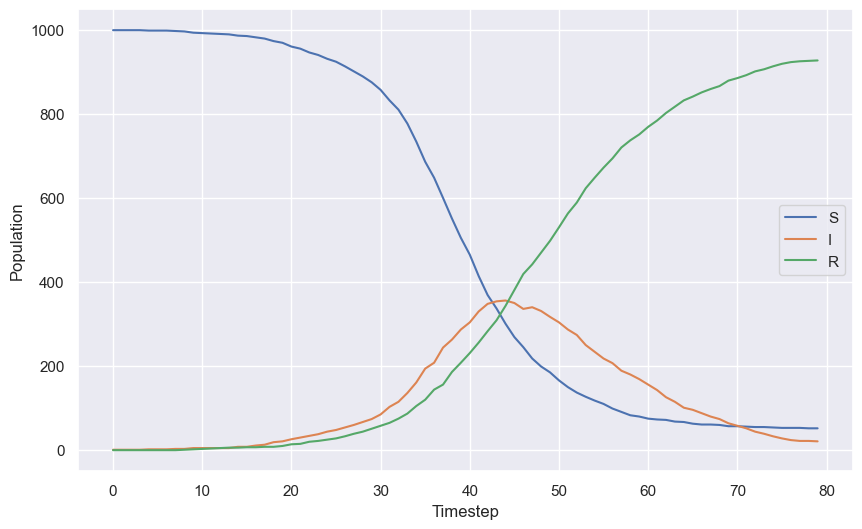

In [380]:
plt.figure(figsize=(10, 6))
sir_sim_state = sir.compute_state(sir_sim)
plt.plot(np.sum(sir_sim_state, axis=1), label=["S", "I", "R"])
plt.xlabel("Timestep")
plt.ylabel("Population")
_ = plt.legend()


In [381]:
epidemic_data = pd.DataFrame(sir_sim_state[:, 0, :], columns=["S", "I", "R"])
epidemic_data

,S,I,R
0,999.0,1.0,0.0
1,999.0,1.0,0.0
2,999.0,1.0,0.0
3,999.0,1.0,0.0
4,998.0,2.0,0.0
...,...,...,...
75,53.0,28.0,919.0
76,53.0,24.0,923.0
77,53.0,22.0,925.0
78,52.0,22.0,926.0


Calculate the log-likelihood for this data given the model.

````{exercise-end}
````

## Data frame computation

````{solution-start} ex4.3
:class: dropdown
````

In [382]:
# add the number of SI and IR transitions. This is easy because they
# comes as an output of the simulation. Otherwise this can be computed
# num_si = epidemic_data.S.diff(-1), num_si = epidemic_data.R.diff(1)
num_transitions = np.sum(sir_sim, axis=-2)

epidemic_data["num_si"] = num_transitions[:, 0]
epidemic_data["num_ir"] = num_transitions[:, 1]

# look at a random middle section of the data
epidemic_data.iloc[28:35, :]

,S,I,R,num_si,num_ir
28,889.0,67.0,44.0,14.0,7.0
29,875.0,74.0,51.0,18.0,7.0
30,857.0,85.0,58.0,25.0,7.0
31,832.0,103.0,65.0,22.0,10.0
32,810.0,115.0,75.0,33.0,12.0
33,777.0,136.0,87.0,43.0,18.0
34,734.0,161.0,105.0,48.0,15.0


In [383]:
# WANT to compute the probability of transition P^{qr}

# need to compute transition rates first
vec_transition_rates = jax.vmap(transition_rates)
si_rate, ir_rate = vec_transition_rates(np.arange(0, 80), sir.compute_state(sir_sim))

In [384]:
# examine output
si_rate[0:10], ir_rate[10:20]

(Array([[0.0003],
        [0.0003],
        [0.0003],
        [0.0003],
        [0.0006],
        [0.0006],
        [0.0006],
        [0.0009],
        [0.0009],
        [0.0015]], dtype=float64),
 Array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1], dtype=float64))

In [385]:
# add to our dataframe
epidemic_data["si_rate"] = si_rate
epidemic_data["ir_rate"] = ir_rate

epidemic_data

,S,I,R,num_si,num_ir,si_rate,ir_rate
0,999.0,1.0,0.0,0.0,0.0,0.0003,0.1
1,999.0,1.0,0.0,0.0,0.0,0.0003,0.1
2,999.0,1.0,0.0,0.0,0.0,0.0003,0.1
3,999.0,1.0,0.0,1.0,0.0,0.0003,0.1
4,998.0,2.0,0.0,0.0,0.0,0.0006,0.1
...,...,...,...,...,...,...,...
75,53.0,28.0,919.0,0.0,4.0,0.0084,0.1
76,53.0,24.0,923.0,0.0,2.0,0.0072,0.1
77,53.0,22.0,925.0,1.0,1.0,0.0066,0.1
78,52.0,22.0,926.0,0.0,1.0,0.0066,0.1


In [386]:
# compute transition probability
epidemic_data["si_prob"] = 1 - np.exp(-si_rate)
epidemic_data["ir_prob"] = 1 - np.exp(-ir_rate)

epidemic_data

,S,I,R,num_si,num_ir,si_rate,ir_rate,si_prob,ir_prob
0,999.0,1.0,0.0,0.0,0.0,0.0003,0.1,0.000300,0.095163
1,999.0,1.0,0.0,0.0,0.0,0.0003,0.1,0.000300,0.095163
2,999.0,1.0,0.0,0.0,0.0,0.0003,0.1,0.000300,0.095163
3,999.0,1.0,0.0,1.0,0.0,0.0003,0.1,0.000300,0.095163
4,998.0,2.0,0.0,0.0,0.0,0.0006,0.1,0.000600,0.095163
...,...,...,...,...,...,...,...,...,...
75,53.0,28.0,919.0,0.0,4.0,0.0084,0.1,0.008365,0.095163
76,53.0,24.0,923.0,0.0,2.0,0.0072,0.1,0.007174,0.095163
77,53.0,22.0,925.0,1.0,1.0,0.0066,0.1,0.006578,0.095163
78,52.0,22.0,926.0,0.0,1.0,0.0066,0.1,0.006578,0.095163


Let's take stock of what we have:

1. Number of units in each state
2. Transition probability for each time step and state

This is all you need to compute the log-likelihood of a binomial random variable!

In [387]:
def log_lik_t_si(row):
    return row.num_si * np.log(row.si_prob) + (row.S - row.num_si) * np.log(
        1 - row.si_prob
    )


def log_lik_t_ir(row):
    return row.num_ir * np.log(row.ir_prob) + (row.I - row.num_ir) * np.log(
        1 - row.ir_prob
    )


def log_lik_t(row):
    return log_lik_t_si(row) + log_lik_t_ir(row)

In [388]:
epidemic_data["log_lik_t"] = epidemic_data.apply(log_lik_t, axis=1)

In [389]:
print(f"log L(X|D) = {np.sum(epidemic_data.log_lik_t[:-1])}")

log L(X|D) = -6752.000000352619


````{solution-end}
````

## Array computation (NumPy)

Just as in the previous session, we now use `numpy` for the computation 

In [390]:
# Step 1 - state counts
S = np.asarray(sir_sim_state[:, 0, 0])
I = np.asarray(sir_sim_state[:, 0, 1])
R = np.asarray(sir_sim_state[:, 0, 2])

S[:5], I[:5], R[:5]

(array([999., 999., 999., 999., 998.]),
 array([1., 1., 1., 1., 2.]),
 array([0., 0., 0., 0., 0.]))

In [391]:
# Step 2 - number of SI and IR transitions at each time step
num_transitions = np.sum(sir_sim, axis=-2)

num_si = num_transitions[:, 0]
num_ir = num_transitions[:, 1]

num_si[28:35], num_ir[28:35]

(Array([14., 18., 25., 22., 33., 43., 48.], dtype=float64),
 Array([ 7.,  7.,  7., 10., 12., 18., 15.], dtype=float64))

In [392]:
# Step 3 - vectorised transition rates for every time step
vec_transition_rates = jax.vmap(transition_rates)
si_rate, ir_rate = vec_transition_rates(np.arange(0, 80), sir.compute_state(sir_sim))


In [393]:
# si_rate comes back with shape (num_steps, 1) because `state[:, 1]` is 2D inside

si_rate = si_rate.squeeze()
ir_rate = np.broadcast_to(np.array(ir_rate), si_rate.shape)

si_rate[:10], ir_rate[10:20]

(Array([0.0003, 0.0003, 0.0003, 0.0003, 0.0006, 0.0006, 0.0006, 0.0009,
        0.0009, 0.0015], dtype=float64),
 array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]))

In [394]:
# Step 4 - transition probabilities, fully vectorised
# (equivalent to epidemic_data['si_prob'] / epidemic_data['ir_prob'] above)
si_prob = 1 - np.exp(-si_rate)
ir_prob = 1 - np.exp(-ir_rate)

si_prob[:5], ir_prob[:5]

(array([0.00029996, 0.00029996, 0.00029996, 0.00029996, 0.00059982]),
 array([0.09516258, 0.09516258, 0.09516258, 0.09516258, 0.09516258]))

In [395]:
# Step 5 - per-time-step log-likelihood, fully vectorised
log_lik_t_si_array = num_si * np.log(si_prob) + (S - num_si) * np.log(1 - si_prob)
log_lik_t_ir_array = num_ir * np.log(ir_prob) + (I - num_ir) * np.log(1 - ir_prob)

log_lik_t = log_lik_t_si_array + log_lik_t_ir_array

log_lik_t[:5]

Array([-0.399701  , -0.399701  , -0.399701  , -8.51127574, -0.798801  ],      dtype=float64)

In [396]:
# Step 6 - overall log-likelihood
logL = np.sum(log_lik_t[:-1])

print(f"log L(X|D) = {logL}")

log L(X|D) = -6752.00000035262


Both approaches give the same log-likelihood, but the array version avoids looping over rows of the data frame.

## Creating a parameterized likelihood function

Performing operations in a dataframe turns out to be restrictive. The goal of model fitting is to estimate parameters based on data and so we want to be able to feed our likelihood _function_ into an optimizer (like in the [Likelihood 1 session](https://gem-epidemics.gitlab.io/practical-epidemics/iddinf/03-likelihood-theory-1.html)). We saw how to use the `scipiy.optimize` function earlier so let's work with that same function.

`optimize` needs a function which it can use to evaluate different parameter values and find the minima for. This implies that we want our likelihood function to have the model parameters as inputs. It should look something like this

```python
log_likelihood_fn(theta)
```

We will once again focus on the SIR chain binomial model. Aggregating events over the fixed time period means that our model parameters are now part of $p^{SI}_{t_s},p^{IR}_{t_s}$. Recall the formula for the transition probabilities:
\begin{align*}
p^{SI}_{t_s}&=1-e^{-\lambda^{SI}(t_s)\delta t_s} \\
p^{IR}_{t_s}&=1-e^{-\lambda^{IR}(t_s)\delta t_s}
\end{align*}
The model parameters are in the _transition rate function_ and thus _related_ to the transition probabilities through these formulas. With this in mind, let's now implement the log-likelihood function

$$
l(X|H) \propto \sum_{s = 0}^{max - 1}\left( k \log p^{SI}_{t_s} + (S_{t_s}-k)\log(1-p^{SI}_{t_s}) + j \log p^{IR}_{t_s} + (I_{t_s}-j)\log(1-p^{IR}_{t_s}) \right)
$$

for this model.

In [397]:
# raw data for first metapopulation again
epi_df = pd.DataFrame(sir_sim_state[:, 0, :], columns=["S", "I", "R"])
epi_df

,S,I,R
0,999.0,1.0,0.0
1,999.0,1.0,0.0
2,999.0,1.0,0.0
3,999.0,1.0,0.0
4,998.0,2.0,0.0
...,...,...,...
75,53.0,28.0,919.0
76,53.0,24.0,923.0
77,53.0,22.0,925.0
78,52.0,22.0,926.0


We are going to use a closure to create this function. More on why soon...

In [398]:
def make_sir_chain_binom_loglik(epidemic_dataframe):
    # data processing steps - convert to array
    epi_array = np.array(epidemic_dataframe)

    # compute change in states
    num_si = np.squeeze(sir_sim[:, :, 0])

    num_ir = np.squeeze(sir_sim[:, :, 1])

    def sir_chain_binom_loglik(theta):
        epsilon = DTYPE(1e-9)  # hardcoded constant

        beta, gamma = theta

        # compute transition rates based on model parameters
        si_rate = beta * epi_array[:, 1] / np.sum(epi_array, axis=-1) + epsilon
        ir_rate = np.ones_like(si_rate) * gamma

        # compute transition probabilities based on transition rates
        p_si = 1 - np.exp(-si_rate)
        p_ir = 1 - np.exp(-ir_rate)

        # compute log-lik
        log_lik_si = num_si * np.log(p_si) + (epi_array[:, 0] - num_si) * np.log(
            1 - p_si
        )
        log_lik_ir = num_ir * np.log(p_ir) + (epi_array[:, 1] - num_ir) * np.log(
            1 - p_ir
        )

        log_lik = log_lik_si + log_lik_ir

        return log_lik

    return sir_chain_binom_loglik

Mathematically, likelihood functions are functions of the parameters of the model. This is why you will see them written as $L(\theta | X)$ where $X$ is the data. We are _conditioning_ on the data. Using the closure pattern here allows us to condition our likelihood on the data - fixing those values but allowing the model parameters to change.

In [399]:
# returns the function equivalent to the mathematical form L(theta|D)
sir_chain_binom_loglik_fn = make_sir_chain_binom_loglik(epi_df)

In [400]:
# compute the likelihood for some parameters values
print(f"log-likelihood = {np.sum(sir_chain_binom_loglik_fn([0.3, 0.1]))}")

log-likelihood = -6770.752496542445


## Sanity check!

Are the two methods the same?

````{solution-start} ex4.3-sanity-check
:class: dropdown
````

In [401]:
# same as before? No output if it does pass
np.testing.assert_almost_equal(
    actual=np.array(epidemic_data.log_lik_t),
    desired=sir_chain_binom_loglik_fn([0.3, 0.1]),
)

In [402]:
pd.DataFrame(
    {
        "function_method": sir_chain_binom_loglik_fn([0.3, 0.1]),
        "dataframe_method": np.array(epidemic_data.log_lik_t),
    }
)

,function_method,dataframe_method
0,-0.399701,-0.399701
1,-0.399701,-0.399701
2,-0.399701,-0.399701
3,-8.511276,-8.511276
4,-0.798801,-0.798801
...,...,...
75,-12.253874,-12.253874
76,-7.285937,-7.285937
77,-9.819352,-9.819352
78,-4.795369,-4.795369


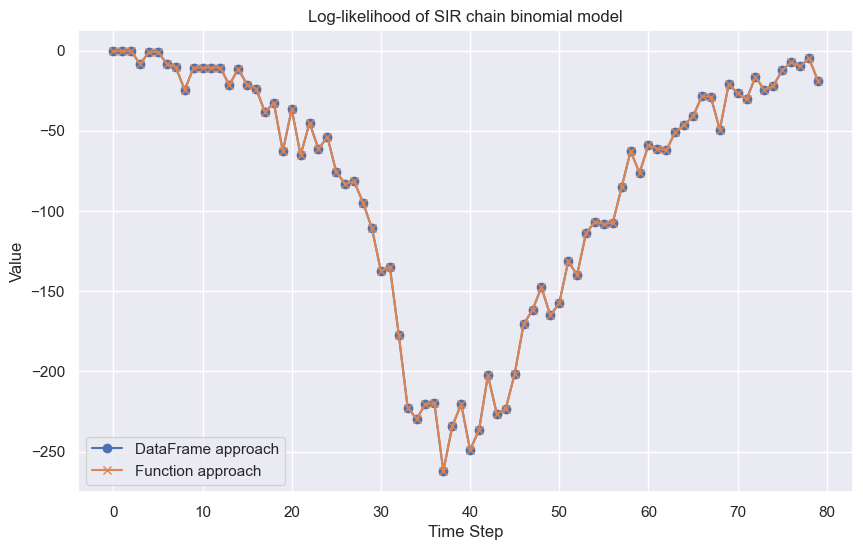

In [403]:
# Plotting
plt.figure(figsize=(10, 6))
plt.plot(np.array(epidemic_data.log_lik_t), label="DataFrame approach", marker="o")
plt.plot(
    sir_chain_binom_loglik_fn((np.float64(0.3), np.float64(0.1))),
    label="Function approach",
    marker="x",
)

# Adding titles and labels
plt.title("Log-likelihood of SIR chain binomial model")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend()

# Show plot
plt.grid(True)
plt.show()

__Note__: numerical errors can arise. The values are close but not quite identical

````{solution-end}
````

## Maximum likelihood estimation

```{exercise}
:label: ex4.4

Compute the MLE of the the likelihood function.
```

````{solution-start} ex4.4
:class: dropdown
````

In [404]:
# import optimizer
from scipy.optimize import minimize

In [405]:
ll_fn = lambda x: -np.sum(sir_chain_binom_loglik_fn(x))

In [406]:
ll_fn([0.3, 0.1])

Array(6770.75249654, dtype=float64)

In [407]:
# initial values on the log scale
initial_parameters = np.array([0.1, 0.1], dtype=np.float32)

opt = minimize(
    ll_fn,
    initial_parameters,
    method="L-BFGS-B",
    jac="3-point",
    options={"finite_diff_rel_step": None},
)


In [408]:
opt

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 6768.965947025681
        x: [ 3.154e-01  1.038e-01]
      nit: 8
      jac: [-4.973e-04 -4.940e-03]
     nfev: 55
     njev: 11
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

In [409]:
print(
    f"{'True values:':<18}beta = {np.round(0.3, 5):<10}gamma = {np.round(0.10, 5):<10}"
)
print(
    f"{'Estimated values:':<18}beta = {np.round(opt.x[0], 5):<10}gamma = {np.round(opt.x[1], 5):<10}"
)

True values:      beta = 0.3       gamma = 0.1       
Estimated values: beta = 0.31537   gamma = 0.10384   


In [410]:
std_errors = np.sqrt(np.diagonal(opt.hess_inv.todense()))
lower_ci = opt.x - 1.96 * std_errors  # 95% CI
upper_ci = opt.x + 1.96 * std_errors

In [411]:
print(
    f"Beta 95% CI:  lower = {np.round(lower_ci[0], 5)}, upper = {np.round(upper_ci[0], 5)}"
)
print(
    f"Gamma 95% CI: lower = {np.round(lower_ci[1], 5)}, upper = {np.round(upper_ci[1], 5)}"
)

Beta 95% CI:  lower = 0.28578, upper = 0.34495
Gamma 95% CI: lower = 0.07026, upper = 0.13743


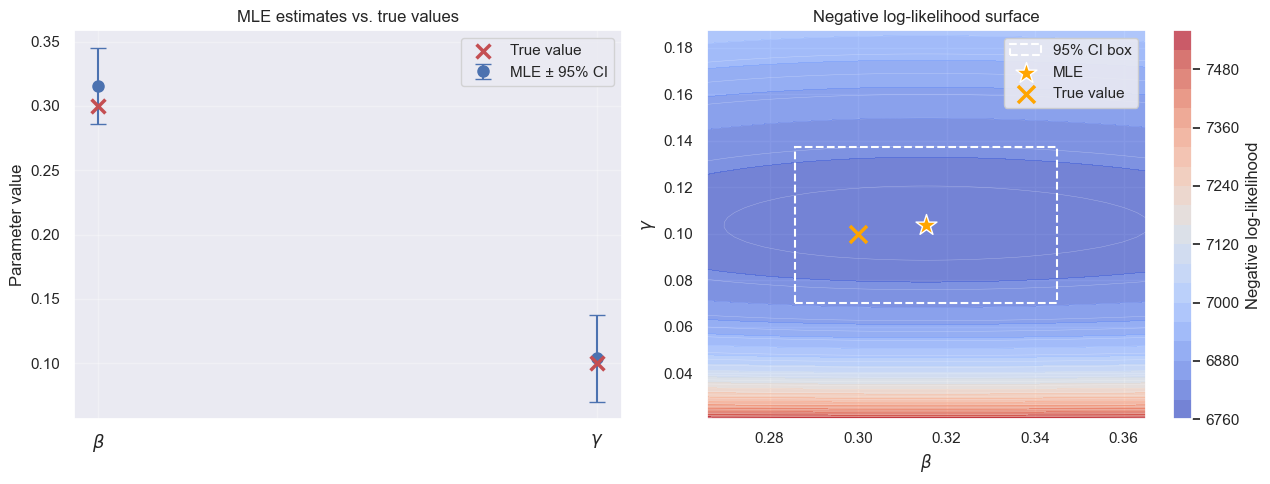

In [412]:
true_values = np.array([0.3, 0.1])
param_names = [r"$\beta$", r"$\gamma$"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1 - MLE vs true value, with 95% CI error bars
ax = axes[0]
x_pos = np.arange(len(param_names))
err = np.array([opt.x - lower_ci, upper_ci - opt.x])

ax.errorbar(
    x_pos,
    opt.x,
    yerr=err,
    fmt="o",
    capsize=6,
    markersize=8,
    color="C0",
    label="MLE ± 95% CI",
    zorder=3,
)
ax.scatter(
    x_pos,
    true_values,
    marker="x",
    s=100,
    color="C3",
    linewidths=2.5,
    label="True value",
    zorder=4,
)
ax.set_xticks(x_pos)
ax.set_xticklabels(param_names, fontsize=13)
ax.set_ylabel("Parameter value")
ax.set_title("MLE estimates vs. true values")
ax.legend()
ax.grid(alpha=0.3)

# Panel 2 - negative log-likelihood surface around the optimum
ax = axes[1]
beta_grid = np.linspace(max(1e-3, lower_ci[0] - 0.02), upper_ci[0] + 0.02, 80)
gamma_grid = np.linspace(max(1e-3, lower_ci[1] - 0.05), upper_ci[1] + 0.05, 80)
B, G = np.meshgrid(beta_grid, gamma_grid)
Z = np.array([[ll_fn([b, g]) for b in beta_grid] for g in gamma_grid])

cf = ax.contourf(B, G, Z, levels=20, cmap="coolwarm", alpha=0.7)
plt.colorbar(cf, ax=ax, label="Negative log-likelihood")
ax.contour(B, G, Z, levels=30, colors="white", linewidths=0.3, alpha=0.4)

# 95% CI box and key points
ax.add_patch(
    plt.Rectangle(
        (lower_ci[0], lower_ci[1]),
        upper_ci[0] - lower_ci[0],
        upper_ci[1] - lower_ci[1],
        fill=False,
        edgecolor="white",
        linestyle="--",
        linewidth=1.5,
        label="95% CI box",
    )
)
ax.scatter(
    *opt.x,
    color="orange",
    marker="*",
    s=250,
    edgecolor="white",
    linewidth=1,
    label="MLE",
    zorder=5,
)
ax.scatter(
    *true_values,
    color="orange",
    marker="x",
    s=150,
    linewidths=2.5,
    label="True value",
    zorder=5,
)
ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"$\gamma$")
ax.set_title("Negative log-likelihood surface")
ax.legend(loc="upper right", framealpha=0.9)

plt.tight_layout()
plt.show()

````{solution-end}
````